# Intrinsic generator identification and held-out validation

The state is $(v,\sigma,q,p,\omega)$. The realization-level split is fixed before model comparison: seeds 0-15 train and seeds 16-23 test. Frozen fits are loaded by default. Set `REFIT=True` to rerun the hierarchy and autonomous-scale validation.

In [1]:
from pathlib import Path
import json, subprocess, sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('Repository root:', ROOT)

REFIT = False

Repository root: /mnt/data/work_release_v3/LagrangianEllipsoid_Corrected_Release_v3/2_github_repository


In [2]:
if REFIT:
    subprocess.run([sys.executable, str(ROOT/'scripts/fit_generator_hierarchy.py')], cwd=ROOT, check=True)
    subprocess.run([sys.executable, str(ROOT/'scripts/fit_autonomous_model.py')], cwd=ROOT, check=True)
    print('Model hierarchy refitted.')
else:
    print('Using frozen model products.')

Using frozen model products.


In [3]:
phase3 = json.loads((ROOT/'data/results/intrinsic_model_b_summary.json').read_text())
final = json.loads((ROOT/'data/results/final_intrinsic_model_summary.json').read_text())
split = json.loads((ROOT/'configs/train_test_split.json').read_text())
print('Train seeds:', split['train_seeds'])
print('Test seeds:', split['test_seeds'])
for model, score in phase3['scores'].items():
    auto = final['autonomous_scores'][model]['conditional_sigma_rmse']
    print(f"{model}: one-step NLL={score['one_step_nll']:.3f}; empirical-scale rollout RMSE={score['rollout_mean_sigma_rmse']:.3f}; autonomous conditional RMSE={auto:.3f}")

Train seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Test seeds: [16, 17, 18, 19, 20, 21, 22, 23]
M0: one-step NLL=0.915; empirical-scale rollout RMSE=0.542; autonomous conditional RMSE=0.361
M1: one-step NLL=0.883; empirical-scale rollout RMSE=0.796; autonomous conditional RMSE=0.747
M2: one-step NLL=0.812; empirical-scale rollout RMSE=0.408; autonomous conditional RMSE=0.095
M3: one-step NLL=0.816; empirical-scale rollout RMSE=0.408; autonomous conditional RMSE=0.093


## Selected model

M2 is the selected sparse intrinsic generator. The aligned component $q$ depends on $(\sigma,q)$; the transverse strain $p$ and vorticity $\omega$ form a coupled rotation block; and the residual in the aspect-ratio equation is affine in $\sigma$. M3 permits all linear couplings but does not improve held-out performance enough to justify the added parameters.

In [4]:
import pandas as pd
coef = pd.read_csv(ROOT/'tables/m2_coefficients_with_bootstrap.csv')
coef.head(24)

,bin,v_low,v_high,parameter,estimate,bootstrap_sem
0,0,-0.001806,1.090245,b_v,0.447818,0.019094
1,0,-0.001806,1.090245,Q_v,0.036380,0.002464
2,0,-0.001806,1.090245,a_0,0.647558,0.128496
3,0,-0.001806,1.090245,a_1,-1.332086,0.185993
4,0,-0.001806,1.090245,c_q0,10.100041,1.298349
5,0,-0.001806,1.090245,c_qsigma,-7.689695,1.634922
6,0,-0.001806,1.090245,c_qq,-7.625463,0.499717
7,0,-0.001806,1.090245,c_p0,0.008199,1.049557
8,0,-0.001806,1.090245,c_pp,-7.622686,0.555105
9,0,-0.001806,1.090245,c_pomega,0.057022,0.586461


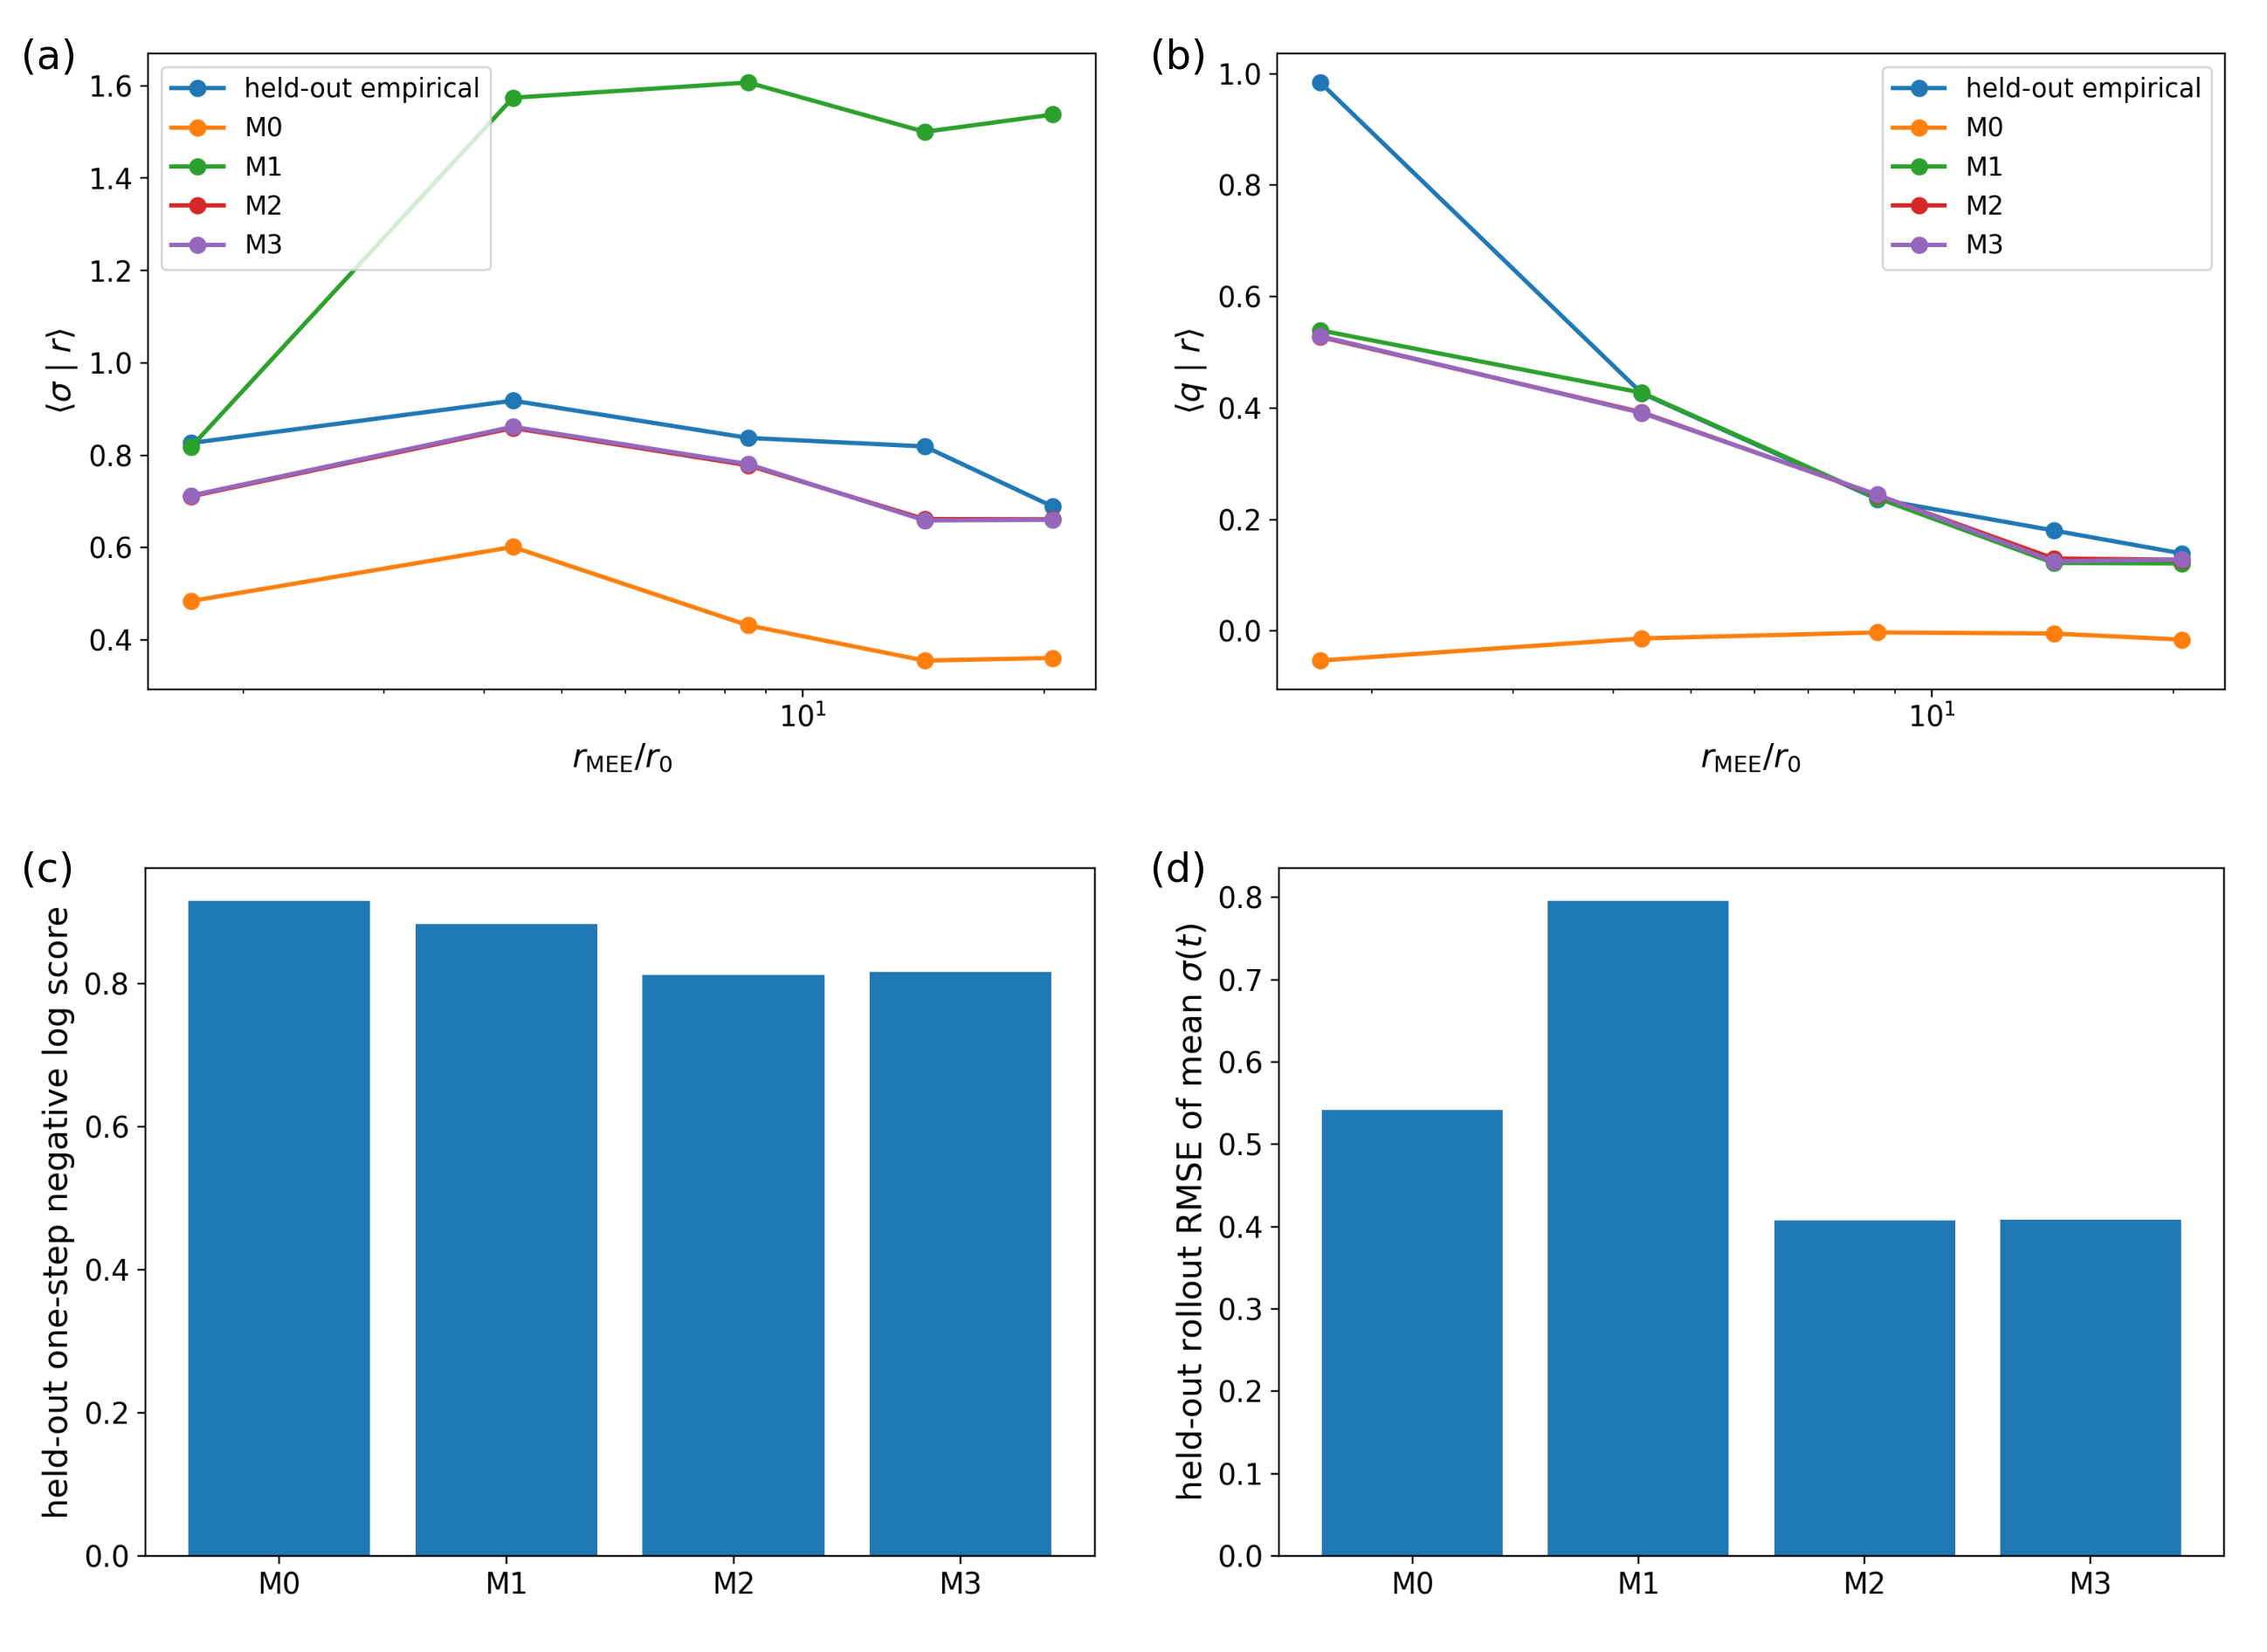

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'figures/main/fig05_model.png'), width=950))

In [6]:
print('Lag sensitivity:')
print(json.dumps(phase3['lag_sensitivity'], indent=2))

Lag sensitivity:
{
  "1": {
    "delta": 0.1,
    "nll": 0.8118989989495142,
    "rmse": 0.7401045199016099,
    "innovation_lag1_corr": [
      0.12525191724670573,
      0.034515254770397734,
      -0.009790656045718759,
      -0.05833721548479477
    ]
  },
  "2": {
    "delta": 0.2,
    "nll": 2.141924370143265,
    "rmse": 0.7802277787523006,
    "innovation_lag1_corr": [
      0.22096612345521918,
      0.4749653727856557,
      0.4566506712386092,
      0.43079582262137756
    ]
  },
  "4": {
    "delta": 0.4,
    "nll": 3.833743460882084,
    "rmse": 0.7910406969569947,
    "innovation_lag1_corr": [
      0.3867372016547141,
      0.5985717497041722,
      0.6264524070918122,
      0.6213832163394883
    ]
  }
}


The Chapman-Kolmogorov discrepancy and innovation correlations show that the Markov closure is approximate. The paper therefore presents M2 as a low-order statistical surrogate, not a trajectory-accurate universal closure.